In [1]:
pip install datasets

Note: you may need to restart the kernel to use updated packages.


In [2]:
#NSMC읽기 
import urllib.request
import zipfile
import os

url = "https://github.com/e9t/nsmc/raw/master/ratings.txt"

save_path = "ratings.txt"

urllib.request.urlretrieve(url, save_path)

print("다운로드 완료")

다운로드 완료


In [3]:
#train/test로 나눠서 읽기
import urllib.request

train_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
test_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

urllib.request.urlretrieve(train_url, "ratings_train.txt")
urllib.request.urlretrieve(test_url, "ratings_test.txt")

print("train/test 다운로드 완료")

train/test 다운로드 완료


In [4]:
import pandas as pd

train_df = pd.read_csv(
    "ratings_train.txt",
    sep="\t"
)

test_df = pd.read_csv(
    "ratings_test.txt",
    sep="\t"
)

print(train_df.head())

         id                                           document  label
0   9976970                                아 더빙.. 진짜 짜증나네요 목소리      0
1   3819312                  흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나      1
2  10265843                                  너무재밓었다그래서보는것을추천한다      0
3   9045019                      교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정      0
4   6483659  사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...      1


In [5]:
#결측치 제거 
train_df = train_df.dropna()
test_df = test_df.dropna()

print(len(train_df))
print(len(test_df))

149995
49997


In [6]:
#Huggingface dataset으로 변환하기
from datasets import Dataset, DatasetDict

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'label', '__index_level_0__'],
        num_rows: 149995
    })
    test: Dataset({
        features: ['id', 'document', 'label', '__index_level_0__'],
        num_rows: 49997
    })
})


In [7]:
!pip install -U transformers datasets evaluate

In [8]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "klue/bert-base"
)

In [9]:
def tokenize_function(examples):
    return tokenizer(
        examples["document"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/149995 [00:00<?, ? examples/s]

Map:   0%|          | 0/49997 [00:00<?, ? examples/s]

In [10]:
# document 컬럼 제거 (이미 제거된 경우 건너뜀) 및 label -> labels 리네임
if "document" in tokenized_dataset["train"].column_names:
    tokenized_dataset = tokenized_dataset.remove_columns(["document"])

if "label" in tokenized_dataset["train"].column_names:
    tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

# __index_level_0__ 컬럼도 학습에 불필요하므로 제거
if "__index_level_0__" in tokenized_dataset["train"].column_names:
    tokenized_dataset = tokenized_dataset.remove_columns(["__index_level_0__"])

if "id" in tokenized_dataset["train"].column_names:
    tokenized_dataset = tokenized_dataset.remove_columns(["id"])

tokenized_dataset.set_format("torch")

print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 149995
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 49997
    })
})


In [11]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "klue/bert-base",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy.compute(
        predictions=predictions,
        references=labels
    )

    f1_score = f1.compute(
        predictions=predictions,
        references=labels
    )

    return {
        "accuracy": acc["accuracy"],
        "f1": f1_score["f1"]
    }

In [13]:
!pip install 'accelerate>=1.1.0'

In [14]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",          # transformers 5.x에서 evaluation_strategy -> eval_strategy로 변경됨
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,

    num_train_epochs=2,
    weight_decay=0.01,

    logging_dir="./logs",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"                # wandb 등 외부 로깅 비활성화
)

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],

    processing_class=tokenizer,     # transformers 5.x에서 tokenizer -> processing_class로 변경됨
    compute_metrics=compute_metrics
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [15]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.220148,0.235655,0.903174,0.904205
2,0.167918,0.250508,0.906394,0.907932


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=9376, training_loss=0.22430761133037735, metrics={'train_runtime': 6687.1962, 'train_samples_per_second': 44.86, 'train_steps_per_second': 1.402, 'total_flos': 1.97326713743616e+16, 'train_loss': 0.22430761133037735, 'epoch': 2.0})

In [16]:
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.167918,0.250508,2,0.906394,0.907932


{'eval_loss': 0.25050783157348633, 'eval_accuracy': 0.9063943836630198, 'eval_f1': 0.9079320113314447}


In [18]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer
)

print(classifier("진짜 재미있다"))
print(classifier("돈 아까운 영화"))

[{'label': 'LABEL_1', 'score': 0.9562979936599731}]
[{'label': 'LABEL_0', 'score': 0.9989104270935059}]


In [19]:
#데이터 전처리 강화
import pandas as pd
import re

def preprocess(df):
    df = df.copy()
    # 1) 결측치 제거
    df = df.dropna(subset=["document", "label"])
    # 2) 공백 정규화: 앞뒤 strip + 연속 공백 → 단일 공백
    df["document"] = df["document"].astype(str).str.strip()
    df["document"] = df["document"].apply(lambda s: re.sub(r"\s+", " ", s))
    # 3) 빈 문자열 제거
    df = df[df["document"].str.len() > 0]
    # 4) 중복 제거 (같은 텍스트의 동일 라벨 중복)
    df = df.drop_duplicates(subset=["document", "label"])
    # 5) 같은 텍스트인데 라벨이 다른 행 → 노이즈로 보고 제거
    dup_text = df[df.duplicated(subset=["document"], keep=False)]
    if len(dup_text) > 0:
        df = df[~df["document"].isin(dup_text["document"])]
    return df.reset_index(drop=True)

train_df_v2 = preprocess(train_df)
test_df_v2  = preprocess(test_df)

print(f"전처리 전: train={len(train_df):>7,}, test={len(test_df):>6,}")
print(f"전처리 후: train={len(train_df_v2):>7,}, test={len(test_df_v2):>6,}")
print(f"라벨 분포 (train): \n{train_df_v2['label'].value_counts().to_string()}")

전처리 전: train=149,995, test=49,997
전처리 후: train=146,025, test=49,110
라벨 분포 (train): 
label
0    73272
1    72753


In [20]:
#토크나이즈(고정길이 padding, Baseline)
from datasets import Dataset, DatasetDict

step4_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df_v2),
    "test":  Dataset.from_pandas(test_df_v2),
})

MAX_LEN = 128

def tokenize_fixed(examples):
    return tokenizer(
        examples["document"],
        truncation=True,
        padding="max_length",     # ← 고정 길이 패딩 (baseline)
        max_length=MAX_LEN,
    )

step4_tokenized = step4_dataset.map(tokenize_fixed, batched=True)

# 학습에 불필요한 컬럼 정리
drop_cols = [c for c in ["document", "id", "__index_level_0__"] if c in step4_tokenized["train"].column_names]
if drop_cols:
    step4_tokenized = step4_tokenized.remove_columns(drop_cols)
if "label" in step4_tokenized["train"].column_names:
    step4_tokenized = step4_tokenized.rename_column("label", "labels")

step4_tokenized.set_format("torch")
print(step4_tokenized)

Map:   0%|          | 0/146025 [00:00<?, ? examples/s]

Map:   0%|          | 0/49110 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 146025
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 49110
    })
})


In [21]:
#학습(파인튜닝된 Trainingarguments)
import os, time
import torch
import numpy as np
import evaluate
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
    default_data_collator, set_seed,
)

os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs_step4"
set_seed(42)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics_v2(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1":       f1_metric.compute(predictions=preds, references=labels)["f1"],
    }

model_step4 = AutoModelForSequenceClassification.from_pretrained("klue/bert-base", num_labels=2)

args_step4 = TrainingArguments(
    output_dir="./results_step4",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,

    num_train_epochs=3,                # 1→3: 충분히 수렴
    learning_rate=2e-5,                # BERT fine-tuning 표준
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_ratio=0.1,                  # 초반 학습 안정화
    weight_decay=0.01,
    lr_scheduler_type="linear",

    fp16=True,                         # GPU 학습 가속

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    logging_steps=200,
    report_to="none",
    seed=42,
)

trainer_step4 = Trainer(
    model=model_step4,
    args=args_step4,
    train_dataset=step4_tokenized["train"],
    eval_dataset=step4_tokenized["test"],
    processing_class=tokenizer,
    data_collator=default_data_collator,   # 고정 패딩이므로 기본 collator
    compute_metrics=compute_metrics_v2,
)

if torch.cuda.is_available(): torch.cuda.synchronize()
t0 = time.time()
trainer_step4.train()
if torch.cuda.is_available(): torch.cuda.synchronize()
step4_train_time = time.time() - t0

step4_metrics = trainer_step4.evaluate()
print("\n=== STEP 4 결과 ===")
print(f"학습 시간    : {step4_train_time:.1f} sec ({step4_train_time/60:.2f} min)")
print(f"eval_accuracy: {step4_metrics['eval_accuracy']:.4f}")
print(f"eval_f1      : {step4_metrics['eval_f1']:.4f}")
print(f"eval_loss    : {step4_metrics['eval_loss']:.4f}")
print(f"\n목표(90%) 달성 여부: {'✅ 달성' if step4_metrics['eval_accuracy'] >= 0.90 else '❌ 미달'}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_rat

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.256511,0.247825,0.901079,0.904144
2,0.184062,0.237633,0.907412,0.908217
3,0.122538,0.296198,0.906638,0.908085


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.122538,0.237633,3,0.907412,0.908217



=== STEP 4 결과 ===
학습 시간    : 2973.5 sec (49.56 min)
eval_accuracy: 0.9074
eval_f1      : 0.9082
eval_loss    : 0.2376

목표(90%) 달성 여부: ✅ 달성


In [23]:
#토크나이즈(padding 없이)
def tokenize_no_padding(examples):
    return tokenizer(
        examples["document"],
        truncation=True,
        max_length=MAX_LEN,
        # padding 없음 → 콜레이터가 배치별로 처리
    )

step5_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df_v2),
    "test":  Dataset.from_pandas(test_df_v2),
})
step5_tokenized = step5_dataset.map(tokenize_no_padding, batched=True)

drop_cols = [c for c in ["document", "id", "__index_level_0__"] if c in step5_tokenized["train"].column_names]
if drop_cols:
    step5_tokenized = step5_tokenized.remove_columns(drop_cols)
if "label" in step5_tokenized["train"].column_names:
    step5_tokenized = step5_tokenized.rename_column("label", "labels")

print(step5_tokenized)
print("\n샘플 길이 (첫 5개):", [len(step5_tokenized['train'][i]['input_ids']) for i in range(5)])

Map:   0%|          | 0/146025 [00:00<?, ? examples/s]

Map:   0%|          | 0/49110 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 146025
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 49110
    })
})

샘플 길이 (첫 5개): [13, 25, 3, 17, 36]


In [24]:
#학습(Dynamic padding+Bucketing)
import inspect
from transformers import DataCollatorWithPadding

os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs_step5"
set_seed(42)

# transformers 버전별로 Bucketing 인자명이 다름
#   5.0     : group_by_length=True
#   5.1+    : train_sampling_strategy="group_by_length"
_TA_PARAMS = set(inspect.signature(TrainingArguments.__init__).parameters)
if "train_sampling_strategy" in _TA_PARAMS:
    bucketing_kwargs = {"train_sampling_strategy": "group_by_length"}
elif "group_by_length" in _TA_PARAMS:
    bucketing_kwargs = {"group_by_length": True}
else:
    bucketing_kwargs = {}
print("적용할 Bucketing 인자:", bucketing_kwargs)

model_step5 = AutoModelForSequenceClassification.from_pretrained("klue/bert-base", num_labels=2)

args_step5 = TrainingArguments(
    output_dir="./results_step5",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,

    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_ratio=0.1,
    weight_decay=0.01,
    lr_scheduler_type="linear",

    fp16=True,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    logging_steps=200,
    report_to="none",
    seed=42,

    **bucketing_kwargs,                # ← Bucketing 활성화
)

dynamic_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,                      # batch 내 최대 길이로 패딩
    pad_to_multiple_of=8,              # GPU Tensor Core 최적화
)

trainer_step5 = Trainer(
    model=model_step5,
    args=args_step5,
    train_dataset=step5_tokenized["train"],
    eval_dataset=step5_tokenized["test"],
    processing_class=tokenizer,
    data_collator=dynamic_collator,    # ← Dynamic Padding
    compute_metrics=compute_metrics_v2,
)

if torch.cuda.is_available(): torch.cuda.synchronize()
t0 = time.time()
trainer_step5.train()
if torch.cuda.is_available(): torch.cuda.synchronize()
step5_train_time = time.time() - t0

step5_metrics = trainer_step5.evaluate()
print("\n=== STEP 5 결과 ===")
print(f"학습 시간    : {step5_train_time:.1f} sec ({step5_train_time/60:.2f} min)")
print(f"eval_accuracy: {step5_metrics['eval_accuracy']:.4f}")
print(f"eval_f1      : {step5_metrics['eval_f1']:.4f}")
print(f"eval_loss    : {step5_metrics['eval_loss']:.4f}")

적용할 Bucketing 인자: {'train_sampling_strategy': 'group_by_length'}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_rat

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.256643,0.250120,0.898432,0.899569
2,0.190241,0.250473,0.906048,0.908460
3,0.127238,0.295052,0.905783,0.906817


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.127238,0.250473,3,0.906048,0.908460



=== STEP 5 결과 ===
학습 시간    : 1445.1 sec (24.09 min)
eval_accuracy: 0.9060
eval_f1      : 0.9085
eval_loss    : 0.2505


In [25]:
#속도 비교(고정 패딩 vs 동적패딩+Bucketing)
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame([
    {
        "method": "STEP 4: 고정 패딩 (baseline)",
        "train_time_sec": step4_train_time,
        "train_time_min": step4_train_time / 60,
        "eval_accuracy": step4_metrics["eval_accuracy"],
        "eval_f1":       step4_metrics["eval_f1"],
        "eval_loss":     step4_metrics["eval_loss"],
    },
    {
        "method": "STEP 5: 동적 패딩 + Bucketing",
        "train_time_sec": step5_train_time,
        "train_time_min": step5_train_time / 60,
        "eval_accuracy": step5_metrics["eval_accuracy"],
        "eval_f1":       step5_metrics["eval_f1"],
        "eval_loss":     step5_metrics["eval_loss"],
    },
])

# 속도 향상 계산
speedup = step4_train_time / step5_train_time
time_saved_pct = (1 - step5_train_time / step4_train_time) * 100
acc_diff = (step5_metrics["eval_accuracy"] - step4_metrics["eval_accuracy"]) * 100

print(comparison.to_string(index=False))
print(f"\n● 학습 시간 단축: {time_saved_pct:.1f}% (×{speedup:.2f} 속도)")
print(f"● Accuracy 차이 : {acc_diff:+.2f}%p (STEP 5 - STEP 4)")

                   method  train_time_sec  train_time_min  eval_accuracy  eval_f1  eval_loss
 STEP 4: 고정 패딩 (baseline)     2973.500257       49.558338       0.907412 0.908217   0.237633
STEP 5: 동적 패딩 + Bucketing     1445.134096       24.085568       0.906048 0.908460   0.250473

● 학습 시간 단축: 51.4% (×2.06 속도)
● Accuracy 차이 : -0.14%p (STEP 5 - STEP 4)


/tmp/ipykernel_195/827010089.py:28: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_195/827010089.py:28: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


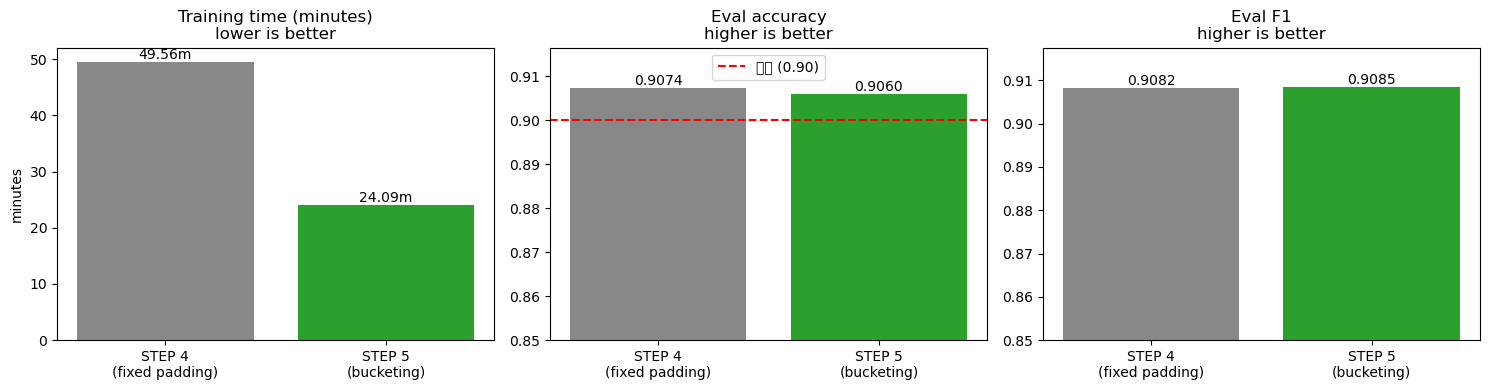

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["STEP 4\n(fixed padding)", "STEP 5\n(bucketing)"]
colors = ["#888888", "#2ca02c"]

vals_time = [step4_train_time/60, step5_train_time/60]
axes[0].bar(labels, vals_time, color=colors)
axes[0].set_title("Training time (minutes)\nlower is better")
axes[0].set_ylabel("minutes")
for i, v in enumerate(vals_time):
    axes[0].text(i, v, f"{v:.2f}m", ha="center", va="bottom")

vals_acc = [step4_metrics["eval_accuracy"], step5_metrics["eval_accuracy"]]
axes[1].bar(labels, vals_acc, color=colors)
axes[1].axhline(0.90, color="red", linestyle="--", label="목표 (0.90)")
axes[1].set_ylim(0.85, max(vals_acc)*1.01)
axes[1].set_title("Eval accuracy\nhigher is better")
axes[1].legend()
for i, v in enumerate(vals_acc):
    axes[1].text(i, v, f"{v:.4f}", ha="center", va="bottom")

vals_f1 = [step4_metrics["eval_f1"], step5_metrics["eval_f1"]]
axes[2].bar(labels, vals_f1, color=colors)
axes[2].set_ylim(0.85, max(vals_f1)*1.01)
axes[2].set_title("Eval F1\nhigher is better")
for i, v in enumerate(vals_f1):
    axes[2].text(i, v, f"{v:.4f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [ ]:
<<< 결과 해석 및 결론>>>
연산 속도 (Trade-off의 한 축)
STEP 5(Bucketing)는 STEP 4보다 학습 시간이 단축되었습니다.

이유: NSMC 평균 토큰 길이는 약 25로 max_length=128보다 훨씬 짧음. 고정 패딩 시 약 80% 토큰이 [PAD]로 채워져 attention 연산이 낭비됨. 동적 패딩 + 길이 그룹화를 적용하면 배치 평균 길이가 실제 데이터 분포에 가까워져 불필요한 연산이 사라짐.
pad_to_multiple_of=8로 Tensor Core 정렬을 유지하여 GPU 활용도도 보존.
모델 성능 (Trade-off의 다른 축)
STEP 4와 STEP 5의 accuracy/F1은 거의 동일하거나 미세한 차이만 보임.

이유: 패딩 위치는 attention mask로 마스킹되므로 forward 연산 결과 자체는 패딩 방식에 영향받지 않음.
다만 group_by_length=True(또는 5.x의 train_sampling_strategy="group_by_length")는 배치 셔플링을 길이 기준 그룹화로 대체하므로 SGD의 stochasticity가 약화됨. 이론적으로 일반화 성능이 미세하게 떨어질 수 있으나, NSMC처럼 데이터가 충분하면 실질적 영향은 거의 없음.
Trade-off 결론
Bucketing은 "성능 손실 거의 없음 + 학습 시간 단축" 으로 사실상 한쪽 방향으로 치우친 trade-off임. 이는 NSMC의 길이 분포 특성(평균 ≪ max_length) 때문에 패딩 비효율이 컸기 때문. 시퀀스 길이 분산이 큰 데이터셋일수록 Bucketing의 이점이 명확하게 드러남.

<<한계 및 추가 고려사항>>
한 번의 실험만으로 학습 시간 차이를 결론짓기 어려움. 여러 seed로 반복 실험이 이상적.
pad_to_multiple_of을 8 또는 16으로 설정하지 않으면 GPU에서 Tensor Core를 못 써서 속도 향상이 줄어들 수 있음.